# 01 - Exploratory Data Analysis
SmartHire: exploring the resume dataset and the merged job corpus (Naukri + LinkedIn).

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

resumes = pd.read_parquet('../data/processed/resumes_clean.parquet')
corpus = pd.read_parquet('../data/processed/job_corpus.parquet')
print('Resumes:', resumes.shape)
print('Job corpus:', corpus.shape)

Resumes: (2483, 4)
Job corpus: (69991, 11)


## Resume dataset overview

In [2]:
resumes.head()

,id,resume_text,category,resume_text_clean
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,Hr,hr administrator marketing associate hr admini...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",Hr,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,Hr,hr director summary over 20 years experience i...
3,27018550,HR SPECIALIST Summary Dedica...,Hr,hr specialist summary dedicated driven and dyn...
4,17812897,HR MANAGER Skill Highlights ...,Hr,hr manager skill highlights hr skills hr depar...


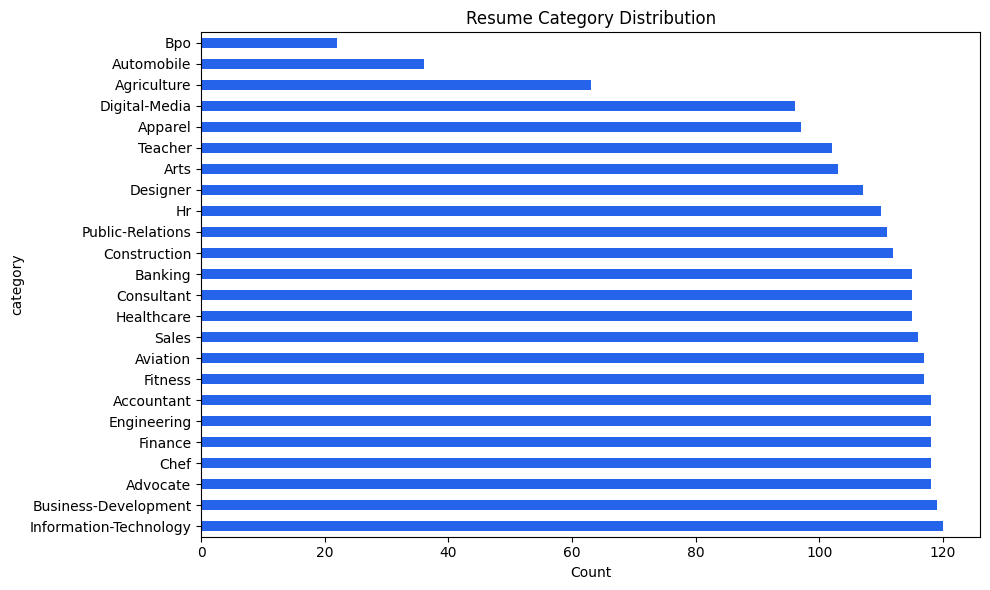

In [3]:
resumes['category'].value_counts().plot(kind='barh', figsize=(10,6), color='#2563eb')
plt.title('Resume Category Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [4]:
word_counts = resumes['resume_text_clean'].str.split().apply(len)
word_counts.describe()

count    2483.000000
mean      808.764801
std       372.336196
min       107.000000
25%       647.500000
50%       755.000000
75%       928.000000
max      5188.000000
Name: resume_text_clean, dtype: float64

## Job corpus overview (Naukri + LinkedIn merged)

In [5]:
corpus.head()

,title,company,location,skills,description,experience,source,description_clean,skills_clean,search_text,job_id
0,Business Development Executive,Ambey Recruitment Services,"Faridabad, India",&lt;br&gt;\r&lt;br&gt;SalesMarketingBusiness D...,Job Description\r&lt;br&gt;\r&lt;br&gt;We Requ...,1-4 years,naukri,job description we required self motivate cand...,salesmarketingbusiness development,business development executive salesmarketingb...,0
1,BPO Hindi Call Center ( CCE ) BPO JOB Fresher ...,Resource Solution,"Delhi, India",,Excellent Opportunity For You To Work With Ind...,,naukri,excellent opportunity for you to work with ind...,,bpo hindi call center cce bpo job fresher 10 1...,1
2,Opening For Hr-recruitment Exe-health Insuranc...,Eresource Infosolutions Pvt. Ltd.,"Noida, India",,"Talent Acquisition, Handling end-to-end recrui...",,naukri,talent acquisition handling end-to-end recruit...,,opening for hr-recruitment exe-health insuranc...,2
3,BCMA - Business Analyst,Citicorp Services India Pvt Ltd,"Mumbai, India",,&lt;P&gt; &lt;B&gt; Core Responsibilities: &lt...,,naukri,core responsibilities end to end m a analysis ...,,bcma - business analyst core responsibilities ...,3
4,Centre Manager - Equity / Channel Sales (franc...,Fortune Human Capital (P) Ltd,"Ranchi, India",,# Responsible for New Client Acquisition of tr...,,naukri,# responsible for new client acquisition of tr...,,centre manager - equity channel sales franchis...,4


In [6]:
corpus['source'].value_counts()

source
linkedin    39994
naukri      29997
Name: count, dtype: int64

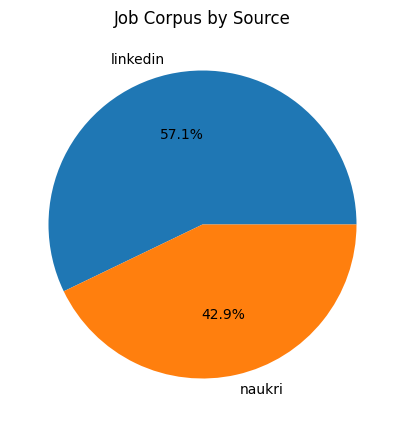

In [7]:
corpus['source'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))
plt.ylabel('')
plt.title('Job Corpus by Source')
plt.show()

In [8]:
# Most common job titles
corpus['title'].value_counts().head(20)

title
Sales Manager                      317
Software Engineer                  188
Project Manager                    182
PHP Developer                      162
Business Development Manager       157
Sales Executive                    144
Senior Software Engineer           131
Java Developer                     123
Business Development Executive     118
Customer Service Representative    115
Business Analyst                   106
Android Developer                  103
Senior Accountant                  101
Receptionist                        90
Registered Nurse                    87
Graphic Designer                    86
Account Manager                     83
Administrative Assistant            81
Software Developer                  80
Assistant Manager                   79
Name: count, dtype: int64

In [9]:
# Description length distribution
corpus['description_clean'].str.split().apply(len).describe()

count    69991.000000
mean       377.880585
std        311.971620
min          0.000000
25%        129.000000
50%        301.000000
75%        553.000000
max       3253.000000
Name: description_clean, dtype: float64

## Takeaways
- Resume categories are reasonably balanced (~100-120 per class), except Automobile and Bpo which are smaller (<40 samples) -- worth watching in the classifier's per-class recall.
- The merged job corpus combines ~30k Naukri postings (India-focused) with ~40k LinkedIn postings (global/US-heavy), giving broad title and skill coverage for the recommender.
- Both sources needed different extraction logic for skills/experience since neither had a clean, consistent schema out of the box.